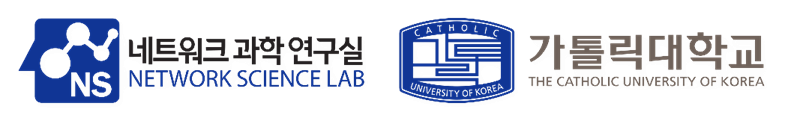

<h1><center><b>💻 Assignment 6:</b> </br>👋 Link Prediction!</center></h1>

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Mining-Spring-2026/blob/main/W6/Assignment_6.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> 🌸 **Submission Reminder**
>
> Please make sure to **submit your `.ipynb` (Jupyter Notebook) file** for grading.  
> Other formats such as **PDF, screenshots, or `.py` files** cannot be accepted.  
>
> Thank you and happy coding! 💻✨

# 1. Building a Friend Recommendation System
### 1.1. Load friend network from edge-list file [data/friend_network.txt](https://github.com/NSLab-CUK/Graph-Mining-Spring-2023/blob/main/W6/data/friend_network.txt)
### 1.2. Complete the following requirements:
- Compute the following coefficient scores to evaluate potential new friendships:
  + Jaccard’s coefficient
  + Adamic-Adar
  + Preferential attachment (PA)
  + SimRank similarity
- Given pair of users who are not yet friends: `[("Ana", "Tino"), ("Mark", "Tim")]`. Calculate and print the metrics for these pairs.

- Recommend the top 3 most likely new friendships out of all unconnected pairs in the network using the **Adamic-Adar index**. Draw the network highlighting nodes by degree and emphasizing these top 3 recommended edges in green dashed lines.

Jaccard's coefficient:
(Ana, Tino) -> 0.142857
(Mark, Tim) -> 0.250000


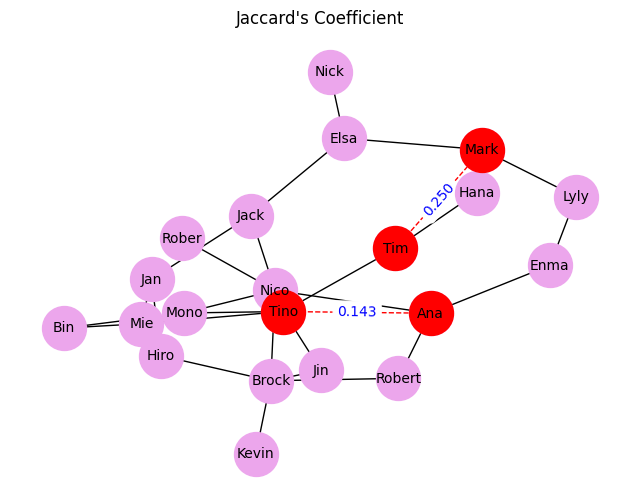


Adamic-Adar index:
(Ana, Tino) -> 0.558111
(Mark, Tim) -> 1.442695


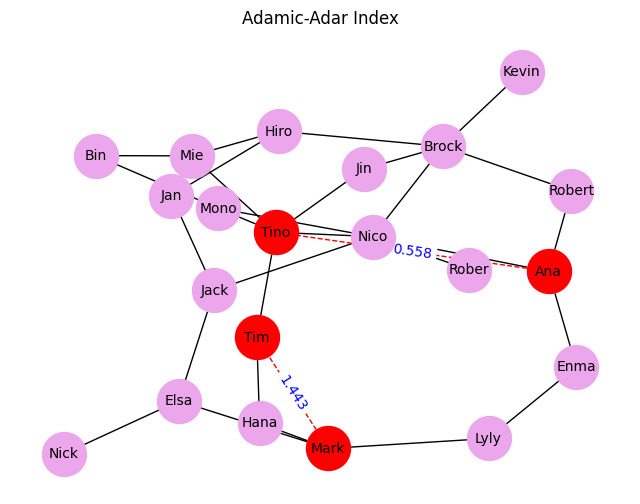


Preferential Attachment score:
(Ana, Tino) -> 15
(Mark, Tim) -> 6


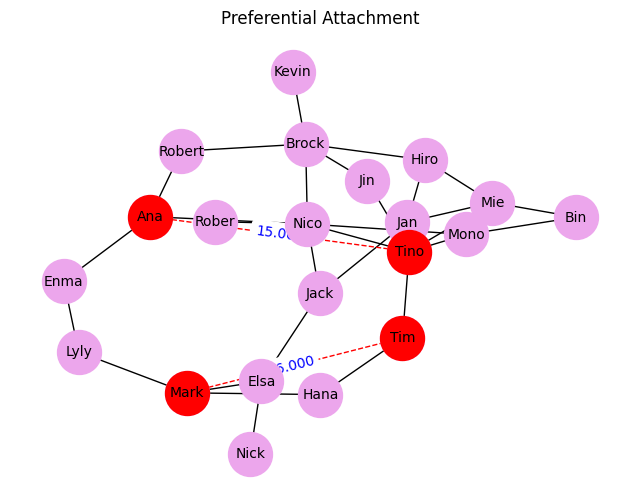


SimRank similarity:
(Ana, Tino) -> 0.302484
(Mark, Tim) -> 0.395129


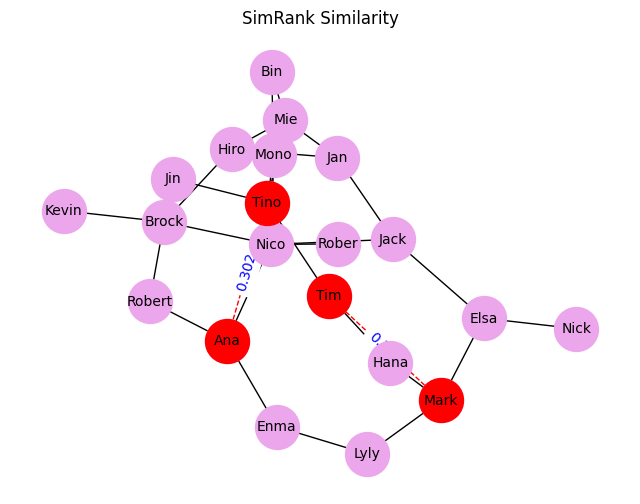

In [3]:

import networkx as nx
import matplotlib.pyplot as plt

G = nx.read_edgelist("data/friend_network.txt")

def draw_coefficient_edges(G, preds, title):
    edge_labels = {}
    target_list = []

    for u, v, p in preds:
        edge_labels[(u, v)] = f"{p:.3f}"
        target_list.append(u)
        target_list.append(v)

    pos = nx.spring_layout(G)

    plt.figure(figsize=(8, 6))
    plt.title(title)
    nx.draw(G, pos,
            node_size=1000,
            node_color='#eca6ec',
            with_labels=True,
            font_size=10)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=target_list,
                           node_size=1000,
                           node_color='r')
    nx.draw_networkx_edges(G, pos, edgelist=node_list, style='dashed', edge_color='r')

    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_color='blue'
    )
    plt.show()

node_list = [("Ana", "Tino"), ("Mark", "Tim")]

print("Jaccard's coefficient:")
jaccard_preds = list(nx.jaccard_coefficient(G, node_list))
for u, v, p in jaccard_preds:
    print(f"({u}, {v}) -> {p:.6f}")
draw_coefficient_edges(G, jaccard_preds, "Jaccard's Coefficient")

print("\nAdamic-Adar index:")
adamic_adar_preds = list(nx.adamic_adar_index(G, node_list))
for u, v, p in adamic_adar_preds:
    print(f"({u}, {v}) -> {p:.6f}")
draw_coefficient_edges(G, adamic_adar_preds, "Adamic-Adar Index")

print("\nPreferential Attachment score:")
pa_preds = list(nx.preferential_attachment(G, node_list))
for u, v, p in pa_preds:
    print(f"({u}, {v}) -> {p}")
draw_coefficient_edges(G, pa_preds, "Preferential Attachment")

print("\nSimRank similarity:")
simrank_preds = list((u, v, nx.simrank_similarity(G, u, v)) for u, v in node_list)
for u, v, p in simrank_preds:
    print(f"({u}, {v}) -> {p:.6f}")
draw_coefficient_edges(G, simrank_preds, "SimRank Similarity")

# 2. Predicting Missing Protein Interactions
### 2.1 Exploring Known Target Pairs

Biological networks are often incomplete. Your task is to predict which proteins are most likely to interact using link prediction algorithms on the `SC-TS` dataset.

+ Load the protein interaction network from [data/SC-TS.txt](data/SC-TS.txt).
+ Read the specific pairs of proteins we want to test from [data/node_pairs.txt](data/node_pairs.txt).
+ Calculate common neighbors (CN), Jaccard (JC), Adamic-Adar (AA), Preferential attachment (PA) and SimRank similarity for these specific pairs.
+ **Improved Visualization**: Instead of plotting the entire massive network ("hairball"), extract the **Ego-Network** (the neighborhood graph) containing these specific nodes and their immediate neighbors. Plot this subgraph to visually understand *why* they might interact (e.g., showing their shared neighbors).

*(Note: In the node pairs file, each row contains 2 columns corresponding to 2 proteins.)*

## 2.2 Finding the Strongest Predictions

Let's identify the most promising unconnected proteins in the entire network that should be tested experimentally!

+ What are the top 5 pairs of predicted protein interactions with the highest **Jaccard (JC)** similarity?
+ What are the top 5 pairs of predicted protein interactions with the highest **Adamic-Adar (AA)** index?
+ What are the top 5 pairs of predicted protein interactions with the highest **Preferential Attachment (PA)** score?

(F17E9.12, F45E1.6) -> 0.11804462
(C50F4.5, T23D8.5) -> 0.11804340
(B0035.8, B0035.10) -> 0.11805700


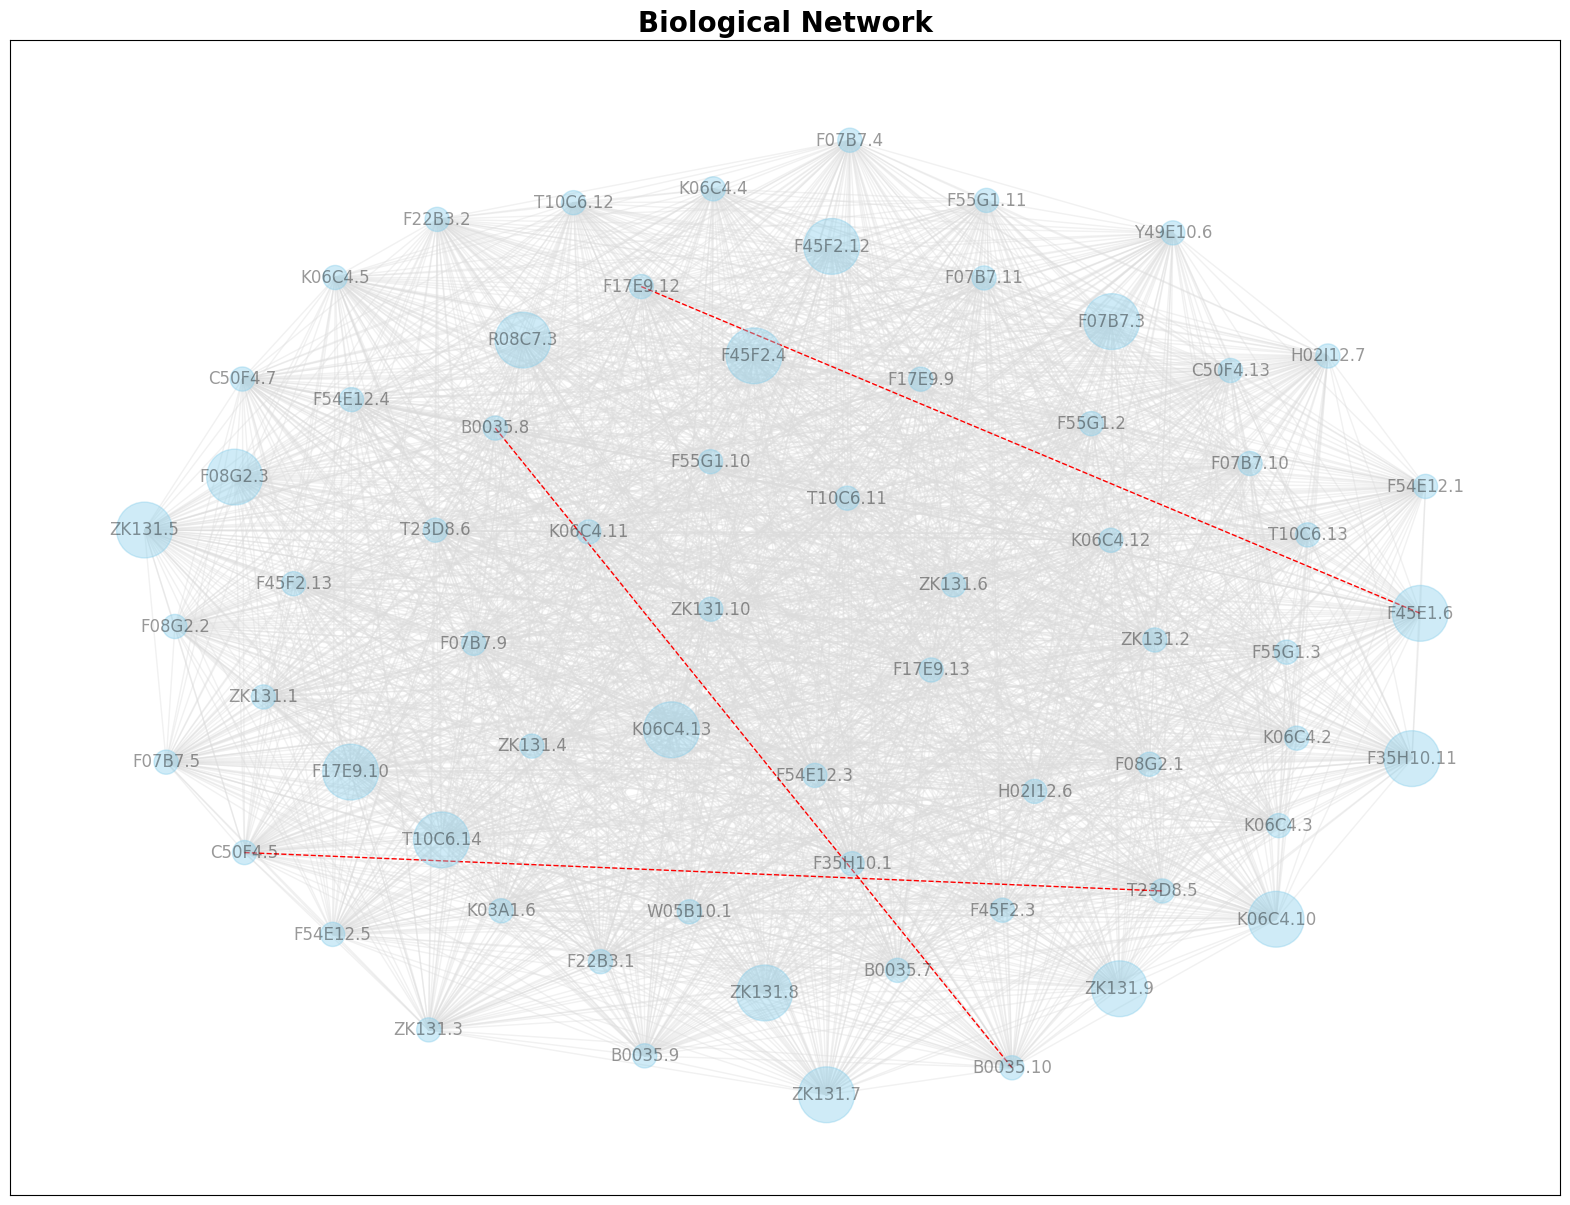

In [7]:
import matplotlib.pyplot as plt

def calculate_simrank_similarity(G, node_list):
    return ((source, target, nx.simrank_similarity(G, source, target)) for source, target in node_list)

def get_largest_component(G):
    components = nx.connected_components(G)
    largest_component = max(components, key=len)
    largest_subgraph = G.subgraph(largest_component)

    return largest_subgraph

def draw_graph_betweenness_centrality(G, largest_component, pos):
    centrality = nx.betweenness_centrality(largest_component, k=15, endpoints=True)
    lpc = nx.community.label_propagation_communities(largest_component)
    community_index = {n: i for i, com in enumerate(lpc) for n in com}

    fig, ax = plt.subplots(figsize=(20, 15))
    node_color = [community_index[n] for n in largest_component]
    node_size = [v * 20000 for v in centrality.values()]
    nx.draw_networkx(
        largest_component,
        pos=pos,
        with_labels=True,
        node_color="skyblue",
        node_size=node_size,
        edge_color="gainsboro",
        alpha=0.4,

    )

    font = {"color": "black", "fontweight": "bold", "fontsize": 20}
    ax.set_title("Biological Network", font)

G = nx.read_weighted_edgelist("data/SC-TS.txt")

largest_component = get_largest_component(G)
pos = nx.spring_layout(largest_component, k=0.2)
draw_graph_betweenness_centrality(G, largest_component, pos)

node_list =  [('F17E9.12', 'F45E1.6'), ('C50F4.5', 'T23D8.5'), ('B0035.8', 'B0035.10')]

preds = calculate_simrank_similarity(G, node_list)

for u, v, p in preds:
    print(f"({u}, {v}) -> {p:.8f}")

target_list = []

for u, v, p in preds:
    target_list.append(u)
    target_list.append(v)

nx.draw_networkx_edges(G, pos, edgelist=node_list, style='dashed', edge_color='r')

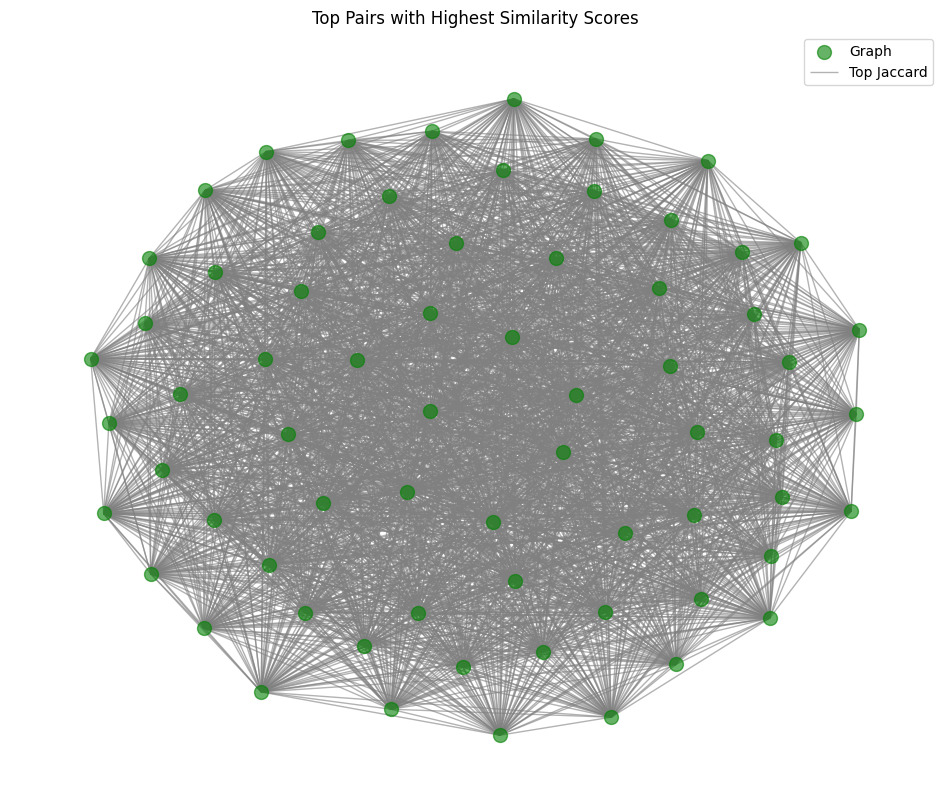

In [17]:
import itertools
import random
from math import log

all_nodes = list(G.nodes())
all_pairs = list(itertools.combinations(all_nodes, 2))

if len(all_pairs) > 10000:
    random.seed(42)
    sample_pairs = random.sample(all_pairs, 10000)
else:
    sample_pairs = all_pairs

jaccard_results = []
adamic_adar_results = []
pa_results = []

top_jaccard = sorted(jaccard_results, key=lambda x: x[2], reverse=True)[:5]
top_adamic_adar = sorted(adamic_adar_results, key=lambda x: x[2], reverse=True)[:5]
top_pa = sorted(pa_results, key=lambda x: x[2], reverse=True)[:5]

plt.figure(figsize=(12, 10))
plt.title("Top Pairs with Highest Similarity Scores")

top_jaccard_edges = [(u, v) for u, v, _ in top_jaccard]
top_aa_edges = [(u, v) for u, v, _ in top_adamic_adar]
top_pa_edges = [(u, v) for u, v, _ in top_pa]

nx.draw(largest_component, pos, node_size=100, node_color='green', edge_color='gray', alpha=0.6)

valid_jaccard = [(u, v) for u, v in top_jaccard_edges if u in pos and v in pos]
valid_aa = [(u, v) for u, v in top_aa_edges if u in pos and v in pos]
valid_pa = [(u, v) for u, v in top_pa_edges if u in pos and v in pos]

nx.draw_networkx_edges(largest_component, pos, edgelist=valid_jaccard, edge_color='red', width=2)
nx.draw_networkx_edges(largest_component, pos, edgelist=valid_aa, edge_color='green', width=2)
nx.draw_networkx_edges(largest_component, pos, edgelist=valid_pa, edge_color='blue', width=2)

plt.legend(['Graph', 'Top Jaccard', 'Top Adamic-Adar', 'Top PA'])
plt.show()